# MachineSense Model Training

## Importing Libraries


In [99]:
import os
import time
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import shutil
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
warnings.filterwarnings(action='ignore')
%matplotlib inline

## Loading the Processed Data

In [100]:


uploaded = ("../02_Data\MachineSense_Processed_Data_with_Metadata.zip",)

In [101]:
zip_name = next(iter(uploaded))

with zipfile.ZipFile(zip_name, 'r') as zip_file:
    zip_file.extractall('MachineSense_Data')

In [102]:
data_path = 'MachineSense_Data/processed_data/'

# Load the processed data.
X_train = pd.read_csv(data_path + 'X_train.csv')
X_validation = pd.read_csv(data_path + 'X_validation.csv')
X_test = pd.read_csv(data_path + 'X_test.csv')

y_train = pd.read_csv(data_path + 'y_train.csv').squeeze('columns')
y_validation = pd.read_csv(data_path + 'y_validation.csv').squeeze('columns')
y_test = pd.read_csv(data_path + 'y_test.csv').squeeze('columns')

# Load the metadata.
train_metadata = pd.read_csv(
    data_path + 'train_metadata.csv',
    parse_dates=['timestamp']
)

validation_metadata = pd.read_csv(
    data_path + 'validation_metadata.csv',
    parse_dates=['timestamp']
)

test_metadata = pd.read_csv(
    data_path + 'test_metadata.csv',
    parse_dates=['timestamp']
)

In [103]:
print('Training:', X_train.shape, y_train.shape)
print('Validation:', X_validation.shape, y_validation.shape)
print('Test:', X_test.shape, y_test.shape)

print('\nMissing values:')
print('Training:', X_train.isnull().sum().sum())
print('Validation:', X_validation.isnull().sum().sum())
print('Test:', X_test.isnull().sum().sum())

print('\nTraining target distribution:')
print(y_train.value_counts().sort_index())

Training: (14142, 14) (14142,)
Validation: (3542, 14) (3542,)
Test: (4566, 14) (4566,)

Missing values:
Training: 0
Validation: 0
Test: 0

Training target distribution:
failure_within_24h
0    11867
1     2275
Name: count, dtype: int64


### Training Class Distribution

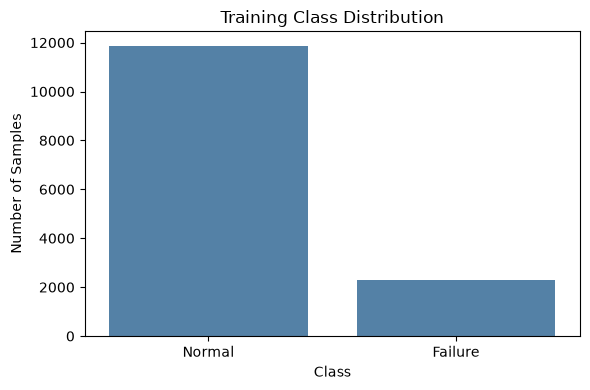

In [104]:
# Visualize the training class distribution.
class_counts = y_train.value_counts().sort_index()

class_distribution = pd.DataFrame({
    'Class': ['Normal', 'Failure'],
    'Count': class_counts.values
})

plt.figure(figsize=(6, 4))

sns.barplot(
    data=class_distribution,
    x='Class',
    y='Count',
    color='steelblue'
)

plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.title('Training Class Distribution')
plt.tight_layout()
plt.show()

### Data Check

In [105]:
print(
    'Targets match metadata:',
    np.array_equal(
        train_metadata['failure_within_24h'].values,
        y_train.values
    ),
    np.array_equal(
        validation_metadata['failure_within_24h'].values,
        y_validation.values
    ),
    np.array_equal(
        test_metadata['failure_within_24h'].values,
        y_test.values
    )
)

train_machines = set(train_metadata['machine_id'])
test_machines = set(test_metadata['machine_id'])

print(
    'Machines shared between train and test:',
    train_machines & test_machines
)

Targets match metadata: True True True
Machines shared between train and test: set()


In [106]:
# Check for data leakage.
leakage_columns = [
    'machine_id',
    'timestamp',
    'failure_type',
    'rul_hours',
    'estimated_repair_cost',
    'failure_within_24h'
]

print('Leakage columns:',
      set(leakage_columns).intersection(X_train.columns))

print('Metadata matches:',
      len(X_train) == len(train_metadata),
      len(X_validation) == len(validation_metadata),
      len(X_test) == len(test_metadata))

print('Test machines:',
      sorted(test_metadata['machine_id'].unique()))

Leakage columns: set()
Metadata matches: True True True
Test machines: [np.int64(6), np.int64(7), np.int64(8), np.int64(14)]


### Model Evaluation Targets

In [107]:
# Define the project evaluation targets.
evaluation_targets = pd.DataFrame({
    'Metric': [
        'Macro-F1',
        'Failure Recall',
        'False Alarm Rate',
        'Early-Warning Recall (12-24h)',
        'Median Prediction Latency'
    ],
    'Target': [
        '>= 0.80',
        '>= 0.80',
        '<= 0.10',
        '>= 0.75',
        '<= 100 ms'
    ]
})

evaluation_targets

,Metric,Target
0,Macro-F1,>= 0.80
1,Failure Recall,>= 0.80
2,False Alarm Rate,<= 0.10
3,Early-Warning Recall (12-24h),>= 0.75
4,Median Prediction Latency,<= 100 ms


## Logistic Regression

In [108]:
# Train and predict.
LR = LogisticRegression(solver='liblinear', max_iter=200)
LR.fit(X_train, y_train)

y_pred_validation_LR = LR.predict(X_validation)
y_prob_validation_LR = LR.predict_proba(X_validation)[:, 1]

### Initial Validation Results

In [109]:
# Confusion matrix.
conf_mat_LR = metrics.confusion_matrix(
    y_validation,
    y_pred_validation_LR
)

tn, fp, fn, tp = conf_mat_LR.ravel()

print('Confusion Matrix:')
print(conf_mat_LR)

print('\nAccuracy:',
      round(metrics.accuracy_score(
          y_validation, y_pred_validation_LR
      ), 3))

print('Macro-F1:',
      round(metrics.f1_score(
          y_validation, y_pred_validation_LR,
          average='macro'
      ), 3))

print('Normal Recall:',
      round(tn / (tn + fp), 3))

print('Failure Recall:',
      round(tp / (tp + fn), 3))

print('False Alarm Rate:',
      round(fp / (fp + tn), 3))

print('Failure Precision:',
      round(metrics.precision_score(
          y_validation, y_pred_validation_LR
      ), 3))

print('Failure F1:',
      round(metrics.f1_score(
          y_validation, y_pred_validation_LR
      ), 3))

print('PR-AUC:',
      round(metrics.average_precision_score(
          y_validation, y_prob_validation_LR
      ), 3))

print('ROC-AUC:',
      round(metrics.roc_auc_score(
          y_validation, y_prob_validation_LR
      ), 3))

Confusion Matrix:
[[2860   37]
 [ 312  333]]

Accuracy: 0.901
Macro-F1: 0.799
Normal Recall: 0.987
Failure Recall: 0.516
False Alarm Rate: 0.013
Failure Precision: 0.9
Failure F1: 0.656
PR-AUC: 0.86
ROC-AUC: 0.954


### Model Parameter Selection

In [110]:
# Test different model parameters.
C_values = [0.01, 0.1, 1, 10]
class_weights = [None, 'balanced']

LR_tuning_results = []

for C in C_values:
    for class_weight in class_weights:

        model = LogisticRegression(
            C=C,
            class_weight=class_weight,
            solver='liblinear',
            max_iter=200
        )

        model.fit(X_train, y_train)

        validation_prob = model.predict_proba(
            X_validation
        )[:, 1]

        LR_tuning_results.append({
            'C': C,
            'Class Weight': class_weight,
            'PR-AUC': metrics.average_precision_score(
                y_validation, validation_prob
            ),
            'ROC-AUC': metrics.roc_auc_score(
                y_validation, validation_prob
            )
        })

LR_tuning_results = pd.DataFrame(
    LR_tuning_results
).sort_values(
    'PR-AUC',
    ascending=False
)

LR_tuning_results.round(3)

,C,Class Weight,PR-AUC,ROC-AUC
4,1.00,NaN,0.860,0.954
5,1.00,balanced,0.860,0.955
6,10.00,NaN,0.859,0.953
7,10.00,balanced,0.857,0.954
3,0.10,balanced,0.851,0.951
2,0.10,NaN,0.837,0.943
1,0.01,balanced,0.756,0.901
0,0.01,NaN,0.627,0.840


### Threshold Selection

In [111]:
# Train the selected Logistic Regression model.
LR = LogisticRegression(
    C=1,
    class_weight=None,
    solver='liblinear',
    max_iter=200
)

LR.fit(X_train, y_train)

y_prob_validation_LR = LR.predict_proba(
    X_validation
)[:, 1]

# Test different classification thresholds.
threshold_grid = np.arange(0.01, 1.00, 0.01)
macro_f1_scores = []

for threshold in threshold_grid:

    validation_pred = (
        y_prob_validation_LR >= threshold
    ).astype(int)

    macro_f1_scores.append(
        metrics.f1_score(
            y_validation,
            validation_pred,
            average='macro'
        )
    )

best_index = np.argmax(macro_f1_scores)

selected_threshold_LR = threshold_grid[best_index]

print('Selected Threshold:',
      round(selected_threshold_LR, 2))

print('Validation Macro-F1:',
      round(macro_f1_scores[best_index], 3))

Selected Threshold: 0.16
Validation Macro-F1: 0.875


In [112]:
# Evaluate the selected threshold.
y_pred_validation_LR = (
    y_prob_validation_LR >= selected_threshold_LR
).astype(int)

conf_mat_LR = metrics.confusion_matrix(
    y_validation,
    y_pred_validation_LR
)

tn, fp, fn, tp = conf_mat_LR.ravel()

print('Confusion Matrix:')
print(conf_mat_LR)

print('\nClassification Report:')
print(metrics.classification_report(
    y_validation,
    y_pred_validation_LR,
    digits=3
))

print('Macro-F1:',
      round(metrics.f1_score(
          y_validation,
          y_pred_validation_LR,
          average='macro'
      ), 3))

print('False Alarm Rate:',
      round(fp / (fp + tn), 3))

print('PR-AUC:',
      round(metrics.average_precision_score(
          y_validation,
          y_prob_validation_LR
      ), 3))

print('ROC-AUC:',
      round(metrics.roc_auc_score(
          y_validation,
          y_prob_validation_LR
      ), 3))

Confusion Matrix:
[[2726  171]
 [ 103  542]]

Classification Report:
              precision    recall  f1-score   support

           0      0.964     0.941     0.952      2897
           1      0.760     0.840     0.798       645

    accuracy                          0.923      3542
   macro avg      0.862     0.891     0.875      3542
weighted avg      0.927     0.923     0.924      3542

Macro-F1: 0.875
False Alarm Rate: 0.059
PR-AUC: 0.86
ROC-AUC: 0.954


### Compare the Default and Selected Thresholds

In [113]:
# Compare the default and selected thresholds.
LR_threshold_comparison = []

for threshold in [0.50, selected_threshold_LR]:

    prediction = (
        y_prob_validation_LR >= threshold
    ).astype(int)

    cm = metrics.confusion_matrix(
        y_validation,
        prediction
    )

    tn_value, fp_value, fn_value, tp_value = cm.ravel()

    LR_threshold_comparison.append({
        'Threshold': threshold,
        'Accuracy': metrics.accuracy_score(
            y_validation, prediction
        ),
        'Macro-F1': metrics.f1_score(
            y_validation, prediction,
            average='macro'
        ),
        'Normal Recall': tn_value / (
            tn_value + fp_value
        ),
        'Failure Recall': tp_value / (
            tp_value + fn_value
        ),
        'False Alarm Rate': fp_value / (
            fp_value + tn_value
        ),
        'Failure Precision': metrics.precision_score(
            y_validation, prediction
        ),
        'Failure F1': metrics.f1_score(
            y_validation, prediction
        )
    })

LR_threshold_comparison = pd.DataFrame(
    LR_threshold_comparison
)

LR_threshold_comparison.round(3)

,Threshold,Accuracy,Macro-F1,Normal Recall,Failure Recall,False Alarm Rate,Failure Precision,Failure F1
0,0.50,0.901,0.799,0.987,0.516,0.013,0.90,0.656
1,0.16,0.923,0.875,0.941,0.840,0.059,0.76,0.798


### Early-Warning Performance and Prediction Latency

In [114]:
# Early-warning performance.
rul_validation = validation_metadata['rul_hours']

true_positive_mask = (
    (y_validation.values == 1) &
    (y_pred_validation_LR == 1)
)

median_lead_time_LR = rul_validation[
    true_positive_mask
].median()

early_period_mask = (
    (y_validation.values == 1) &
    (rul_validation.values >= 12) &
    (rul_validation.values <= 24)
)

early_warning_recall_LR = y_pred_validation_LR[
    early_period_mask
].mean()



In [115]:
# Measure single-sample prediction latency.
single_sample = X_validation.iloc[[0]]

LR.predict_proba(single_sample)

latency_values = []

for run in range(1000):

    start_time = time.perf_counter()
    LR.predict_proba(single_sample)
    end_time = time.perf_counter()

    latency_values.append(
        (end_time - start_time) * 1000
    )

prediction_latency_LR = np.median(latency_values)
latency_p95_LR = np.percentile(latency_values, 95)

print('Median Prediction Latency:',
      round(prediction_latency_LR, 3), 'ms')

print('95th Percentile Latency:',
      round(latency_p95_LR, 3), 'ms')

Median Prediction Latency: 0.628 ms
95th Percentile Latency: 1.295 ms


In [116]:
# Store the Logistic Regression validation results.
normal_recall_LR = tn / (tn + fp)
failure_recall_LR = tp / (tp + fn)

LR_validation_results = pd.DataFrame([{
    'Model': 'Logistic Regression',
    'Threshold': selected_threshold_LR,
    'Macro-F1': metrics.f1_score(
        y_validation,
        y_pred_validation_LR,
        average='macro'
    ),
    'Normal Recall': normal_recall_LR,
    'Failure Recall': failure_recall_LR,
    'False Alarm Rate': fp / (fp + tn),
    'Failure Precision': metrics.precision_score(
        y_validation,
        y_pred_validation_LR
    ),
    'Failure F1': metrics.f1_score(
        y_validation,
        y_pred_validation_LR
    ),
    'PR-AUC': metrics.average_precision_score(
        y_validation,
        y_prob_validation_LR
    ),
    'ROC-AUC': metrics.roc_auc_score(
        y_validation,
        y_prob_validation_LR
    ),
    'Accuracy': metrics.accuracy_score(
        y_validation,
        y_pred_validation_LR
    ),
    'Median Lead Time (h)': median_lead_time_LR,
    'Early Recall (12-24h)': early_warning_recall_LR,
    'Latency (ms)': prediction_latency_LR,
    'Latency P95 (ms)': latency_p95_LR
}])

LR_validation_results.round(3)

,Model,Threshold,Macro-F1,Normal Recall,Failure Recall,False Alarm Rate,Failure Precision,Failure F1,PR-AUC,ROC-AUC,Accuracy,Median Lead Time (h),Early Recall (12-24h),Latency (ms),Latency P95 (ms)
0,Logistic Regression,0.16,0.875,0.941,0.84,0.059,0.76,0.798,0.86,0.954,0.923,10.415,0.781,0.628,1.295


### Feature Coefficients

In [117]:
# Logistic Regression feature coefficients.
LR_coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': LR.coef_[0]
})

LR_coefficients['Absolute Coefficient'] = (
    LR_coefficients['Coefficient'].abs()
)

LR_coefficients = LR_coefficients.sort_values(
    'Absolute Coefficient',
    ascending=False
)

LR_coefficients.round(3)

,Feature,Coefficient,Absolute Coefficient
0,vibration_rms,13.541,13.541
1,temperature_motor,12.016,12.016
2,current_phase_avg,10.290,10.290
4,rpm,-7.736,7.736
13,operating_mode_peak,-4.723,4.723
3,pressure_level,-4.712,4.712
8,machine_type_Compressor,-2.690,2.690
12,operating_mode_normal,-1.940,1.940
7,machine_type_CNC,-1.705,1.705
9,machine_type_Pump,-1.577,1.577


## Decision Tree

### Initial Model and Overfitting Check

In [118]:
# Train and predict.
DTC = DecisionTreeClassifier(random_state=42)
DTC.fit(X_train, y_train)

y_pred_train_DTC = DTC.predict(X_train)
y_pred_validation_DTC = DTC.predict(X_validation)

print('Training Accuracy:',
      round(metrics.accuracy_score(
          y_train, y_pred_train_DTC
      ), 3))

print('Validation Accuracy:',
      round(metrics.accuracy_score(
          y_validation, y_pred_validation_DTC
      ), 3))

print('Training Macro-F1:',
      round(metrics.f1_score(
          y_train, y_pred_train_DTC,
          average='macro'
      ), 3))

print('Validation Macro-F1:',
      round(metrics.f1_score(
          y_validation, y_pred_validation_DTC,
          average='macro'
      ), 3))

Training Accuracy: 1.0
Validation Accuracy: 0.906
Training Macro-F1: 1.0
Validation Macro-F1: 0.816


### Model Parameter Selection

In [119]:
# Test different Decision Tree parameters.
max_depth_values = [3, 5, 7, 10, None]
min_samples_leaf_values = [1, 5, 10, 20, 50]
class_weights = [None, 'balanced']

DTC_tuning_results = []

for max_depth in max_depth_values:
    for min_samples_leaf in min_samples_leaf_values:
        for class_weight in class_weights:

            model = DecisionTreeClassifier(
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                class_weight=class_weight,
                random_state=42
            )

            model.fit(X_train, y_train)

            validation_prob = model.predict_proba(
                X_validation
            )[:, 1]

            DTC_tuning_results.append({
                'Max Depth': max_depth,
                'Min Samples Leaf': min_samples_leaf,
                'Class Weight': class_weight,
                'PR-AUC': metrics.average_precision_score(
                    y_validation, validation_prob
                ),
                'ROC-AUC': metrics.roc_auc_score(
                    y_validation, validation_prob
                )
            })

DTC_tuning_results = pd.DataFrame(
    DTC_tuning_results
).sort_values(
    'PR-AUC',
    ascending=False
)

DTC_tuning_results.head(10).round(3)

,Max Depth,Min Samples Leaf,Class Weight,PR-AUC,ROC-AUC
48,NaN,50,NaN,0.863,0.960
46,NaN,20,NaN,0.841,0.941
38,10.0,50,NaN,0.820,0.934
39,10.0,50,balanced,0.809,0.936
49,NaN,50,balanced,0.809,0.939
36,10.0,20,NaN,0.799,0.916
34,10.0,10,NaN,0.782,0.889
29,7.0,50,balanced,0.779,0.926
32,10.0,5,NaN,0.774,0.871
30,10.0,1,NaN,0.740,0.833


In [120]:
# Train the selected Decision Tree model.
DTC = DecisionTreeClassifier(
    max_depth=None,
    min_samples_leaf=50,
    class_weight=None,
    random_state=42
)

DTC.fit(X_train, y_train)

y_pred_train_DTC = DTC.predict(X_train)
y_pred_validation_DTC = DTC.predict(X_validation)

y_prob_validation_DTC = DTC.predict_proba(
    X_validation
)[:, 1]

print('Tree Depth:', DTC.get_depth())
print('Number of Leaves:', DTC.get_n_leaves())

print('Training Macro-F1:',
      round(metrics.f1_score(
          y_train, y_pred_train_DTC,
          average='macro'
      ), 3))

print('Validation Macro-F1:',
      round(metrics.f1_score(
          y_validation, y_pred_validation_DTC,
          average='macro'
      ), 3))

print('Validation PR-AUC:',
      round(metrics.average_precision_score(
          y_validation, y_prob_validation_DTC
      ), 3))

Tree Depth: 17
Number of Leaves: 98
Training Macro-F1: 0.89
Validation Macro-F1: 0.836
Validation PR-AUC: 0.863


### Threshold Selection

In [121]:
# Test different classification thresholds.
threshold_grid = np.arange(0.01, 1.00, 0.01)
macro_f1_scores = []

for threshold in threshold_grid:

    validation_pred = (
        y_prob_validation_DTC >= threshold
    ).astype(int)

    macro_f1_scores.append(
        metrics.f1_score(
            y_validation,
            validation_pred,
            average='macro'
        )
    )

best_index = np.argmax(macro_f1_scores)

selected_threshold_DTC = threshold_grid[best_index]

print('Selected Threshold:',
      round(selected_threshold_DTC, 2))

print('Validation Macro-F1:',
      round(macro_f1_scores[best_index], 3))

Selected Threshold: 0.19
Validation Macro-F1: 0.873


In [122]:
# Evaluate the selected threshold.
y_pred_validation_DTC = (
    y_prob_validation_DTC >= selected_threshold_DTC
).astype(int)

conf_mat_DTC = metrics.confusion_matrix(
    y_validation,
    y_pred_validation_DTC
)

tn, fp, fn, tp = conf_mat_DTC.ravel()

print('Confusion Matrix:')
print(conf_mat_DTC)

print('\nClassification Report:')
print(metrics.classification_report(
    y_validation,
    y_pred_validation_DTC,
    digits=3
))

print('Macro-F1:',
      round(metrics.f1_score(
          y_validation,
          y_pred_validation_DTC,
          average='macro'
      ), 3))

print('False Alarm Rate:',
      round(fp / (fp + tn), 3))

print('PR-AUC:',
      round(metrics.average_precision_score(
          y_validation,
          y_prob_validation_DTC
      ), 3))

print('ROC-AUC:',
      round(metrics.roc_auc_score(
          y_validation,
          y_prob_validation_DTC
      ), 3))

Confusion Matrix:
[[2710  187]
 [  96  549]]

Classification Report:
              precision    recall  f1-score   support

           0      0.966     0.935     0.950      2897
           1      0.746     0.851     0.795       645

    accuracy                          0.920      3542
   macro avg      0.856     0.893     0.873      3542
weighted avg      0.926     0.920     0.922      3542

Macro-F1: 0.873
False Alarm Rate: 0.065
PR-AUC: 0.863
ROC-AUC: 0.96


### Compare the Default and Selected Thresholds

In [123]:
# Compare the default and selected thresholds.
DTC_threshold_comparison = []

for threshold in [0.50, selected_threshold_DTC]:

    y_pred = (
        y_prob_validation_DTC >= threshold
    ).astype(int)

    tn_temp, fp_temp, fn_temp, tp_temp = (
        metrics.confusion_matrix(
            y_validation,
            y_pred
        ).ravel()
    )

    DTC_threshold_comparison.append({
        'Threshold': threshold,
        'Accuracy': metrics.accuracy_score(
            y_validation, y_pred
        ),
        'Macro-F1': metrics.f1_score(
            y_validation, y_pred, average='macro'
        ),
        'Normal Recall': tn_temp / (tn_temp + fp_temp),
        'Failure Recall': tp_temp / (tp_temp + fn_temp),
        'False Alarm Rate': fp_temp / (fp_temp + tn_temp),
        'Failure Precision': metrics.precision_score(
            y_validation, y_pred
        ),
        'Failure F1': metrics.f1_score(
            y_validation, y_pred
        )
    })

DTC_threshold_comparison = pd.DataFrame(
    DTC_threshold_comparison
)

DTC_threshold_comparison.round(3)

,Threshold,Accuracy,Macro-F1,Normal Recall,Failure Recall,False Alarm Rate,Failure Precision,Failure F1
0,0.50,0.913,0.836,0.977,0.628,0.023,0.856,0.725
1,0.19,0.920,0.873,0.935,0.851,0.065,0.746,0.795


### Early-Warning Performance and Prediction Latency

In [124]:
# Early-warning performance.
true_positive_mask = (
    (y_validation.values == 1) &
    (y_pred_validation_DTC == 1)
)

median_lead_time_DTC = validation_metadata.loc[
    true_positive_mask,
    'rul_hours'
].median()

early_period_mask = (
    (y_validation.values == 1) &
    (validation_metadata['rul_hours'].values >= 12) &
    (validation_metadata['rul_hours'].values <= 24)
)

early_warning_recall_DTC = y_pred_validation_DTC[
    early_period_mask
].mean()

# Measure single-sample prediction latency.
single_sample = X_validation.iloc[[0]]
DTC.predict_proba(single_sample)

latency_values = []

for run in range(1000):

    start_time = time.perf_counter()
    DTC.predict_proba(single_sample)
    end_time = time.perf_counter()

    latency_values.append(
        (end_time - start_time) * 1000
    )

prediction_latency_DTC = np.median(latency_values)
latency_p95_DTC = np.percentile(latency_values, 95)

print('Median Warning Lead Time:',
      round(median_lead_time_DTC, 3), 'hours')

print('Early-Warning Recall (12-24h):',
      round(early_warning_recall_DTC, 3))

print('Median Prediction Latency:',
      round(prediction_latency_DTC, 3), 'ms')

print('95th Percentile Latency:',
      round(latency_p95_DTC, 3), 'ms')

Median Warning Lead Time: 10.47 hours
Early-Warning Recall (12-24h): 0.788
Median Prediction Latency: 0.669 ms
95th Percentile Latency: 3.001 ms


In [125]:
# Store the Decision Tree validation results.
normal_recall_DTC = tn / (tn + fp)
failure_recall_DTC = tp / (tp + fn)

DTC_validation_results = pd.DataFrame([{
    'Model': 'Decision Tree',
    'Threshold': selected_threshold_DTC,
    'Macro-F1': metrics.f1_score(
        y_validation,
        y_pred_validation_DTC,
        average='macro'
    ),
    'Normal Recall': normal_recall_DTC,
    'Failure Recall': failure_recall_DTC,
    'False Alarm Rate': fp / (fp + tn),
    'Failure Precision': metrics.precision_score(
        y_validation,
        y_pred_validation_DTC
    ),
    'Failure F1': metrics.f1_score(
        y_validation,
        y_pred_validation_DTC
    ),
    'PR-AUC': metrics.average_precision_score(
        y_validation,
        y_prob_validation_DTC
    ),
    'ROC-AUC': metrics.roc_auc_score(
        y_validation,
        y_prob_validation_DTC
    ),
    'Accuracy': metrics.accuracy_score(
        y_validation,
        y_pred_validation_DTC
    ),
    'Median Lead Time (h)': median_lead_time_DTC,
    'Early Recall (12-24h)': early_warning_recall_DTC,
    'Latency (ms)': prediction_latency_DTC,
    'Latency P95 (ms)': latency_p95_DTC
}])

# Compare the two models.
model_comparison = pd.concat(
    [LR_validation_results, DTC_validation_results],
    ignore_index=True
)

model_comparison.round(3)

,Model,Threshold,Macro-F1,Normal Recall,Failure Recall,False Alarm Rate,Failure Precision,Failure F1,PR-AUC,ROC-AUC,Accuracy,Median Lead Time (h),Early Recall (12-24h),Latency (ms),Latency P95 (ms)
0,Logistic Regression,0.16,0.875,0.941,0.840,0.059,0.760,0.798,0.860,0.954,0.923,10.415,0.781,0.628,1.295
1,Decision Tree,0.19,0.873,0.935,0.851,0.065,0.746,0.795,0.863,0.960,0.920,10.470,0.788,0.669,3.001


### Feature Importance

In [126]:
# Decision Tree feature importance.
DTC_feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': DTC.feature_importances_
})

DTC_feature_importance = DTC_feature_importance.sort_values(
    'Importance',
    ascending=False
)

DTC_feature_importance.round(3)

,Feature,Importance
1,temperature_motor,0.400
4,rpm,0.242
0,vibration_rms,0.138
2,current_phase_avg,0.069
3,pressure_level,0.054
13,operating_mode_peak,0.050
5,hours_since_maintenance,0.044
9,machine_type_Pump,0.002
8,machine_type_Compressor,0.000
7,machine_type_CNC,0.000


## Random Forest

### Model Parameter Selection

In [127]:
print("--- Training Random Forest ---")

rf_param_grid = [
    {'n_estimators': 100, 'max_depth': 10, 'min_samples_leaf': 10, 'class_weight': None},
    {'n_estimators': 200, 'max_depth': 15, 'min_samples_leaf': 5, 'class_weight': None},
    {'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 10, 'class_weight': 'balanced'},
    {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 20, 'class_weight': 'balanced'}
]

rf_tuning_results = []

for params in rf_param_grid:

    rf_candidate = RandomForestClassifier(
        **params,
        random_state=42,
        n_jobs=-1
    )

    rf_candidate.fit(X_train, y_train)

    val_probs = rf_candidate.predict_proba(X_validation)[:, 1]

    rf_tuning_results.append({
        **params,
        'PR-AUC': metrics.average_precision_score(y_validation, val_probs),
        'ROC-AUC': metrics.roc_auc_score(y_validation, val_probs)
    })

rf_tuning_df = (
    pd.DataFrame(rf_tuning_results)
    .sort_values('PR-AUC', ascending=False)
)

print("Top RF Configurations:")
print(rf_tuning_df.round(3).head())

RFC = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    class_weight=None,
    random_state=42,
    n_jobs=-1
)

RFC.fit(X_train, y_train)

# Probabilities
y_prob_train_RFC = RFC.predict_proba(X_train)[:, 1]
y_prob_val_RFC = RFC.predict_proba(X_validation)[:, 1]



--- Training Random Forest ---
Top RF Configurations:
   n_estimators  max_depth  min_samples_leaf class_weight  PR-AUC  ROC-AUC
1           200       15.0                 5          NaN   0.922    0.982
0           100       10.0                10          NaN   0.903    0.978
3           300        NaN                20     balanced   0.899    0.978
2           200       10.0                10     balanced   0.892    0.977


### Overfitting Check

In [128]:
train_pr_auc_rf = metrics.average_precision_score(
    y_train,
    y_prob_train_RFC
)

val_pr_auc_rf = metrics.average_precision_score(
    y_validation,
    y_prob_val_RFC
)

train_roc_auc_rf = metrics.roc_auc_score(
    y_train,
    y_prob_train_RFC
)

val_roc_auc_rf = metrics.roc_auc_score(
    y_validation,
    y_prob_val_RFC
)

pr_auc_gap_rf = train_pr_auc_rf - val_pr_auc_rf
roc_auc_gap_rf = train_roc_auc_rf - val_roc_auc_rf

rf_overfitting_results = pd.DataFrame([{
    'Train PR-AUC': train_pr_auc_rf,
    'Validation PR-AUC': val_pr_auc_rf,
    'PR-AUC Gap': pr_auc_gap_rf,
    'Train ROC-AUC': train_roc_auc_rf,
    'Validation ROC-AUC': val_roc_auc_rf,
    'ROC-AUC Gap': roc_auc_gap_rf
}])

print("\n--- Random Forest Overfitting Check ---")
print(rf_overfitting_results.round(3))

if pr_auc_gap_rf > 0.05 or roc_auc_gap_rf > 0.05:
    print("Potential overfitting detected.")
else:
    print("No strong evidence of overfitting.")




--- Random Forest Overfitting Check ---
   Train PR-AUC  Validation PR-AUC  PR-AUC Gap  Train ROC-AUC  \
0         0.994              0.922       0.071          0.999   

   Validation ROC-AUC  ROC-AUC Gap  
0               0.982        0.016  
Potential overfitting detected.


### Threshold Selection

In [129]:
threshold_grid = np.arange(0.01, 1.00, 0.01)

threshold_results_rf = []

for t in threshold_grid:

    y_pred_threshold = (
        y_prob_val_RFC >= t
    ).astype(int)

    tn_t, fp_t, fn_t, tp_t = metrics.confusion_matrix(
        y_validation,
        y_pred_threshold
    ).ravel()

    threshold_results_rf.append({
        'Threshold': t,
        'Macro-F1': metrics.f1_score(
            y_validation,
            y_pred_threshold,
            average='macro'
        ),
        'Failure F1': metrics.f1_score(
            y_validation,
            y_pred_threshold
        ),
        'Failure Recall': tp_t / (tp_t + fn_t),
        'Failure Precision': metrics.precision_score(
            y_validation,
            y_pred_threshold,
            zero_division=0
        ),
        'Normal Recall': tn_t / (tn_t + fp_t),
        'False Alarm Rate': fp_t / (fp_t + tn_t),
        'Accuracy': metrics.accuracy_score(
            y_validation,
            y_pred_threshold
        )
    })

threshold_comparison_rf = pd.DataFrame(
    threshold_results_rf
)

selected_threshold_RFC = threshold_comparison_rf.loc[
    threshold_comparison_rf['Macro-F1'].idxmax(),
    'Threshold'
]

print("\n--- Threshold Comparison ---")
print(
    threshold_comparison_rf
    .sort_values('Macro-F1', ascending=False)
    .head(10)
    .round(3)
)

print(
    f"\nSelected Threshold for Random Forest: "
    f"{selected_threshold_RFC:.2f}"
)


# Final predictions using selected threshold
y_pred_val_RFC = (
    y_prob_val_RFC >= selected_threshold_RFC
).astype(int)




--- Threshold Comparison ---
    Threshold  Macro-F1  Failure F1  Failure Recall  Failure Precision  \
18       0.19     0.914       0.862           0.902              0.824   
17       0.18     0.914       0.861           0.910              0.818   
20       0.21     0.914       0.861           0.890              0.833   
19       0.20     0.914       0.860           0.896              0.827   
16       0.17     0.913       0.860           0.919              0.808   
21       0.22     0.912       0.857           0.878              0.837   
25       0.26     0.912       0.856           0.851              0.861   
24       0.25     0.911       0.855           0.856              0.854   
22       0.23     0.911       0.855           0.868              0.842   
27       0.28     0.911       0.853           0.834              0.873   

    Normal Recall  False Alarm Rate  Accuracy  
18          0.957             0.043     0.947  
17          0.955             0.045     0.947  
20         

### Classification Report

In [130]:
print("\n--- Random Forest Classification Report ---")

print(
    metrics.classification_report(
        y_validation,
        y_pred_val_RFC,
        target_names=['Normal', 'Failure'],
        digits=3
    )
)


--- Random Forest Classification Report ---
              precision    recall  f1-score   support

      Normal      0.978     0.957     0.967      2897
     Failure      0.824     0.902     0.862       645

    accuracy                          0.947      3542
   macro avg      0.901     0.930     0.914      3542
weighted avg      0.950     0.947     0.948      3542



### Confusion Matrix

In [131]:
cm_rf = metrics.confusion_matrix(
    y_validation,
    y_pred_val_RFC
)

print("\n--- Random Forest Confusion Matrix ---")
print(cm_rf)

tn, fp, fn, tp = cm_rf.ravel()

print(f"True Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")


--- Random Forest Confusion Matrix ---
[[2773  124]
 [  63  582]]
True Negatives : 2773
False Positives: 124
False Negatives: 63
True Positives : 582


### Compare the Default and Selected Thresholds

In [132]:
# Compare the default and selected thresholds.
RFC_threshold_comparison = threshold_comparison_rf[
    np.isclose(
        threshold_comparison_rf['Threshold'],
        0.50
    ) |
    np.isclose(
        threshold_comparison_rf['Threshold'],
        selected_threshold_RFC
    )
].copy()

RFC_threshold_comparison.round(3)

,Threshold,Macro-F1,Failure F1,Failure Recall,Failure Precision,Normal Recall,False Alarm Rate,Accuracy
18,0.19,0.914,0.862,0.902,0.824,0.957,0.043,0.947
49,0.50,0.832,0.713,0.575,0.937,0.991,0.009,0.916


### Prediction Latency

In [133]:

single_sample = X_validation.iloc[[0]]

RFC.predict_proba(single_sample)

latency_values = []

for run in range(1000):

    start_time = time.perf_counter()
    RFC.predict_proba(single_sample)
    end_time = time.perf_counter()

    latency_values.append(
        (end_time - start_time) * 1000
    )

prediction_latency_RF = np.median(latency_values)
latency_p95_RF = np.percentile(latency_values, 95)

print('Median Prediction Latency:',
      round(prediction_latency_RF, 3), 'ms')

print('95th Percentile Latency:',
      round(latency_p95_RF, 3), 'ms')


Median Prediction Latency: 49.916 ms
95th Percentile Latency: 92.294 ms


### Early-Warning Performance

In [134]:
tp_mask_rf = (
    (y_validation.values == 1) &
    (y_pred_val_RFC == 1)
)

med_lead_rf = validation_metadata.loc[
    tp_mask_rf,
    'rul_hours'
].median()

early_mask = (
    (y_validation.values == 1) &
    (validation_metadata['rul_hours'].between(12, 24))
)

early_recall_rf = y_pred_val_RFC[early_mask].mean()



### Final Validation Results

In [135]:
RFC_validation_results = pd.DataFrame([{

    'Model': 'Random Forest',

    'Threshold': selected_threshold_RFC,

    'Macro-F1': metrics.f1_score(
        y_validation,
        y_pred_val_RFC,
        average='macro'
    ),

    'Normal Recall': tn / (tn + fp),

    'Failure Recall': tp / (tp + fn),

    'False Alarm Rate': fp / (fp + tn),

    'Failure Precision': metrics.precision_score(
        y_validation,
        y_pred_val_RFC,
        zero_division=0
    ),

    'Failure F1': metrics.f1_score(
        y_validation,
        y_pred_val_RFC
    ),

    'PR-AUC': metrics.average_precision_score(
        y_validation,
        y_prob_val_RFC
    ),

    'ROC-AUC': metrics.roc_auc_score(
        y_validation,
        y_prob_val_RFC
    ),

    'Accuracy': metrics.accuracy_score(
        y_validation,
        y_pred_val_RFC
    ),

    'Median Lead Time (h)': med_lead_rf,

    'Early Recall (12-24h)': early_recall_rf,

    'Latency (ms)': prediction_latency_RF,
'Latency P95 (ms)': latency_p95_RF

}])


####DISPLAY FINAL RESULTS

In [136]:
print("FINAL RANDOM FOREST VALIDATION RESULTS")
print(
    RFC_validation_results.round(3).to_string(index=False)
)

FINAL RANDOM FOREST VALIDATION RESULTS
        Model  Threshold  Macro-F1  Normal Recall  Failure Recall  False Alarm Rate  Failure Precision  Failure F1  PR-AUC  ROC-AUC  Accuracy  Median Lead Time (h)  Early Recall (12-24h)  Latency (ms)  Latency P95 (ms)
Random Forest       0.19     0.914          0.957           0.902             0.043              0.824       0.862   0.922    0.982     0.947                 10.44                  0.834        49.916            92.294


## Gradient Boosting

### Model Parameter Selection

In [137]:
print("\n--- Training Gradient Boosting ---")

gb_param_grid = [
    {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.8},
    {'n_estimators': 150, 'learning_rate': 0.1, 'max_depth': 4, 'subsample': 0.8},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 5, 'subsample': 1.0}
]

gb_tuning_results = []
for params in gb_param_grid:
    gb_candidate = GradientBoostingClassifier(**params, random_state=42)
    gb_candidate.fit(X_train, y_train)
    val_probs = gb_candidate.predict_proba(X_validation)[:, 1]

    gb_tuning_results.append({
        **params,
        'PR-AUC': metrics.average_precision_score(y_validation, val_probs),
        'ROC-AUC': metrics.roc_auc_score(y_validation, val_probs)
    })

gb_tuning_df = pd.DataFrame(gb_tuning_results).sort_values('PR-AUC', ascending=False)
print("Top GB Configurations:\n", gb_tuning_df.round(3).head())

GBC = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    random_state=42
)

GBC.fit(X_train, y_train)

y_prob_train_GBC = GBC.predict_proba(X_train)[:, 1]
y_prob_val_GBC = GBC.predict_proba(X_validation)[:, 1]


--- Training Gradient Boosting ---
Top GB Configurations:
    n_estimators  learning_rate  max_depth  subsample  PR-AUC  ROC-AUC
2           200           0.05          5        1.0   0.857    0.953
1           150           0.10          4        0.8   0.854    0.951
0           100           0.05          3        0.8   0.840    0.931


### Overfitting Check

In [138]:
train_pr_auc_gb = metrics.average_precision_score(
    y_train,
    y_prob_train_GBC
)

val_pr_auc_gb = metrics.average_precision_score(
    y_validation,
    y_prob_val_GBC
)

train_roc_auc_gb = metrics.roc_auc_score(
    y_train,
    y_prob_train_GBC
)

val_roc_auc_gb = metrics.roc_auc_score(
    y_validation,
    y_prob_val_GBC
)

pr_auc_gap_gb = train_pr_auc_gb - val_pr_auc_gb
roc_auc_gap_gb = train_roc_auc_gb - val_roc_auc_gb

gb_overfitting_results = pd.DataFrame([{
    'Train PR-AUC': train_pr_auc_gb,
    'Validation PR-AUC': val_pr_auc_gb,
    'PR-AUC Gap': pr_auc_gap_gb,
    'Train ROC-AUC': train_roc_auc_gb,
    'Validation ROC-AUC': val_roc_auc_gb,
    'ROC-AUC Gap': roc_auc_gap_gb
}])

print("\n--- Gradient Boosting Overfitting Check ---")
print(gb_overfitting_results.round(3))

if pr_auc_gap_gb > 0.05 or roc_auc_gap_gb > 0.05:
    print("Potential overfitting detected.")
else:
    print("No strong evidence of overfitting.")



--- Gradient Boosting Overfitting Check ---
   Train PR-AUC  Validation PR-AUC  PR-AUC Gap  Train ROC-AUC  \
0         0.993              0.854       0.139          0.998   

   Validation ROC-AUC  ROC-AUC Gap  
0               0.951        0.047  
Potential overfitting detected.


### Threshold Selection

In [139]:
threshold_grid_gb = np.arange(0.01, 1.00, 0.01)
threshold_results_gb = []

for t in threshold_grid_gb:

    y_pred_threshold = (
        y_prob_val_GBC >= t
    ).astype(int)

    tn_t, fp_t, fn_t, tp_t = metrics.confusion_matrix(
        y_validation,
        y_pred_threshold
    ).ravel()

    threshold_results_gb.append({
        'Threshold': t,

        'Macro-F1': metrics.f1_score(
            y_validation,
            y_pred_threshold,
            average='macro'
        ),

        'Failure F1': metrics.f1_score(
            y_validation,
            y_pred_threshold
        ),

        'Failure Recall': tp_t / (tp_t + fn_t),

        'Failure Precision': metrics.precision_score(
            y_validation,
            y_pred_threshold,
            zero_division=0
        ),

        'Normal Recall': tn_t / (tn_t + fp_t),

        'False Alarm Rate': fp_t / (fp_t + tn_t),

        'Accuracy': metrics.accuracy_score(
            y_validation,
            y_pred_threshold
        )
    })


threshold_comparison_gb = pd.DataFrame(
    threshold_results_gb)

selected_threshold_GBC = threshold_comparison_gb.loc[
    threshold_comparison_gb['Macro-F1'].idxmax(),
    'Threshold']

print("\n--- Gradient Boosting Threshold Comparison ---")

print(
    threshold_comparison_gb
    .sort_values('Macro-F1', ascending=False)
    .head(10)
    .round(3))

print(
    f"\nSelected Threshold for Gradient Boosting: "
    f"{selected_threshold_GBC:.2f}")


# Final predictions using selected threshold
y_pred_val_GBC = (
    y_prob_val_GBC >= selected_threshold_GBC
).astype(int)


--- Gradient Boosting Threshold Comparison ---
    Threshold  Macro-F1  Failure F1  Failure Recall  Failure Precision  \
8        0.09     0.865       0.781           0.803              0.760   
9        0.10     0.864       0.779           0.789              0.769   
10       0.11     0.860       0.771           0.766              0.776   
7        0.08     0.860       0.773           0.812              0.738   
11       0.12     0.856       0.764           0.752              0.777   
6        0.07     0.854       0.765           0.829              0.710   
12       0.13     0.851       0.754           0.732              0.778   
15       0.16     0.850       0.752           0.709              0.800   
14       0.15     0.850       0.752           0.715              0.793   
13       0.14     0.849       0.750           0.719              0.784   

    Normal Recall  False Alarm Rate  Accuracy  
8           0.943             0.057     0.918  
9           0.947             0.053     0

### Classification Report

In [140]:
print("\n--- Gradient Boosting Classification Report ---")

print(
    metrics.classification_report(
        y_validation,
        y_pred_val_GBC,
        target_names=['Normal', 'Failure'],
        digits=3
    )
)


--- Gradient Boosting Classification Report ---
              precision    recall  f1-score   support

      Normal      0.956     0.943     0.949      2897
     Failure      0.760     0.803     0.781       645

    accuracy                          0.918      3542
   macro avg      0.858     0.873     0.865      3542
weighted avg      0.920     0.918     0.919      3542



### Confusion Matrix

In [141]:
cm_gb = metrics.confusion_matrix(
    y_validation,
    y_pred_val_GBC
)

print("\n--- Gradient Boosting Confusion Matrix ---")
print(cm_gb)

tn, fp, fn, tp = cm_gb.ravel()

print(f"True Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")



--- Gradient Boosting Confusion Matrix ---
[[2733  164]
 [ 127  518]]
True Negatives : 2733
False Positives: 164
False Negatives: 127
True Positives : 518


### Compare the Default and Selected Thresholds

In [142]:
# Compare the default and selected thresholds.
GBC_threshold_comparison = threshold_comparison_gb[
    np.isclose(
        threshold_comparison_gb['Threshold'],
        0.50
    ) |
    np.isclose(
        threshold_comparison_gb['Threshold'],
        selected_threshold_GBC
    )
].copy()

GBC_threshold_comparison.round(3)

,Threshold,Macro-F1,Failure F1,Failure Recall,Failure Precision,Normal Recall,False Alarm Rate,Accuracy
8,0.09,0.865,0.781,0.803,0.760,0.943,0.057,0.918
49,0.50,0.783,0.625,0.470,0.935,0.993,0.007,0.898


### Prediction Latency

In [143]:
single_sample = X_validation.iloc[[0]]

GBC.predict_proba(single_sample)

latency_values = []

for run in range(1000):

    start_time = time.perf_counter()
    GBC.predict_proba(single_sample)
    end_time = time.perf_counter()

    latency_values.append(
        (end_time - start_time) * 1000
    )

prediction_latency_GB = np.median(latency_values)
latency_p95_GB = np.percentile(latency_values, 95)

print('Median Prediction Latency:',
      round(prediction_latency_GB, 3), 'ms')

print('95th Percentile Latency:',
      round(latency_p95_GB, 3), 'ms')

Median Prediction Latency: 0.774 ms
95th Percentile Latency: 1.152 ms


### Early-Warning Performance

In [144]:
tp_mask_gb = (
    (y_validation.values == 1) &
    (y_pred_val_GBC == 1)
)

med_lead_gb = validation_metadata.loc[
    tp_mask_gb,
    'rul_hours'
].median()

early_mask = (
    (y_validation.values == 1) &
    (validation_metadata['rul_hours'].between(12, 24))
)

early_recall_gb = y_pred_val_GBC[early_mask].mean()


### Final Validation Results

In [145]:
GBC_validation_results = pd.DataFrame([{

    'Model': 'Gradient Boosting',

    'Threshold': selected_threshold_GBC,

    'Macro-F1': metrics.f1_score(
        y_validation,
        y_pred_val_GBC,
        average='macro'
    ),

    'Normal Recall': tn / (tn + fp),

    'Failure Recall': tp / (tp + fn),

    'False Alarm Rate': fp / (fp + tn),

    'Failure Precision': metrics.precision_score(
        y_validation,
        y_pred_val_GBC,
        zero_division=0
    ),

    'Failure F1': metrics.f1_score(
        y_validation,
        y_pred_val_GBC
    ),

    'PR-AUC': metrics.average_precision_score(
        y_validation,
        y_prob_val_GBC
    ),

    'ROC-AUC': metrics.roc_auc_score(
        y_validation,
        y_prob_val_GBC
    ),

    'Accuracy': metrics.accuracy_score(
        y_validation,
        y_pred_val_GBC
    ),

    'Median Lead Time (h)': med_lead_gb,

    'Early Recall (12-24h)': early_recall_gb,

    'Latency (ms)': prediction_latency_GB,
'Latency P95 (ms)': latency_p95_GB

}])

####Compile GB results

In [146]:
print("FINAL GRADIENT BOOSTING VALIDATION RESULTS")

print(
    GBC_validation_results.round(3).to_string(index=False)
)

FINAL GRADIENT BOOSTING VALIDATION RESULTS
            Model  Threshold  Macro-F1  Normal Recall  Failure Recall  False Alarm Rate  Failure Precision  Failure F1  PR-AUC  ROC-AUC  Accuracy  Median Lead Time (h)  Early Recall (12-24h)  Latency (ms)  Latency P95 (ms)
Gradient Boosting       0.09     0.865          0.943           0.803             0.057               0.76       0.781   0.854    0.951     0.918                  9.82                  0.709         0.774             1.152


## Random Forest and Gradient Boosting Feature Importance

In [147]:
RFC_feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': RFC.feature_importances_
}).sort_values('Importance', ascending=False)

GBC_feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': GBC.feature_importances_
}).sort_values('Importance', ascending=False)

In [148]:
print('Random Forest Feature Importance:')
display(RFC_feature_importance.round(3))

print('Gradient Boosting Feature Importance:')
display(GBC_feature_importance.round(3))

Random Forest Feature Importance:


,Feature,Importance
1,temperature_motor,0.252
4,rpm,0.198
0,vibration_rms,0.178
2,current_phase_avg,0.136
5,hours_since_maintenance,0.092
3,pressure_level,0.053
13,operating_mode_peak,0.019
12,operating_mode_normal,0.016
11,operating_mode_idle,0.012
6,ambient_temp,0.011


Gradient Boosting Feature Importance:


,Feature,Importance
1,temperature_motor,0.287
4,rpm,0.237
0,vibration_rms,0.138
5,hours_since_maintenance,0.111
2,current_phase_avg,0.086
3,pressure_level,0.054
13,operating_mode_peak,0.040
11,operating_mode_idle,0.016
9,machine_type_Pump,0.014
7,machine_type_CNC,0.010


## Final Model Comparison

In [149]:
updated_comparison = pd.concat(
    [
        LR_validation_results,
        DTC_validation_results,
        RFC_validation_results,
        GBC_validation_results
    ],
    ignore_index=True
)

display(updated_comparison.round(3))

,Model,Threshold,Macro-F1,Normal Recall,Failure Recall,False Alarm Rate,Failure Precision,Failure F1,PR-AUC,ROC-AUC,Accuracy,Median Lead Time (h),Early Recall (12-24h),Latency (ms),Latency P95 (ms)
0,Logistic Regression,0.16,0.875,0.941,0.840,0.059,0.760,0.798,0.860,0.954,0.923,10.415,0.781,0.628,1.295
1,Decision Tree,0.19,0.873,0.935,0.851,0.065,0.746,0.795,0.863,0.960,0.920,10.470,0.788,0.669,3.001
2,Random Forest,0.19,0.914,0.957,0.902,0.043,0.824,0.862,0.922,0.982,0.947,10.440,0.834,49.916,92.294
3,Gradient Boosting,0.09,0.865,0.943,0.803,0.057,0.760,0.781,0.854,0.951,0.918,9.820,0.709,0.774,1.152


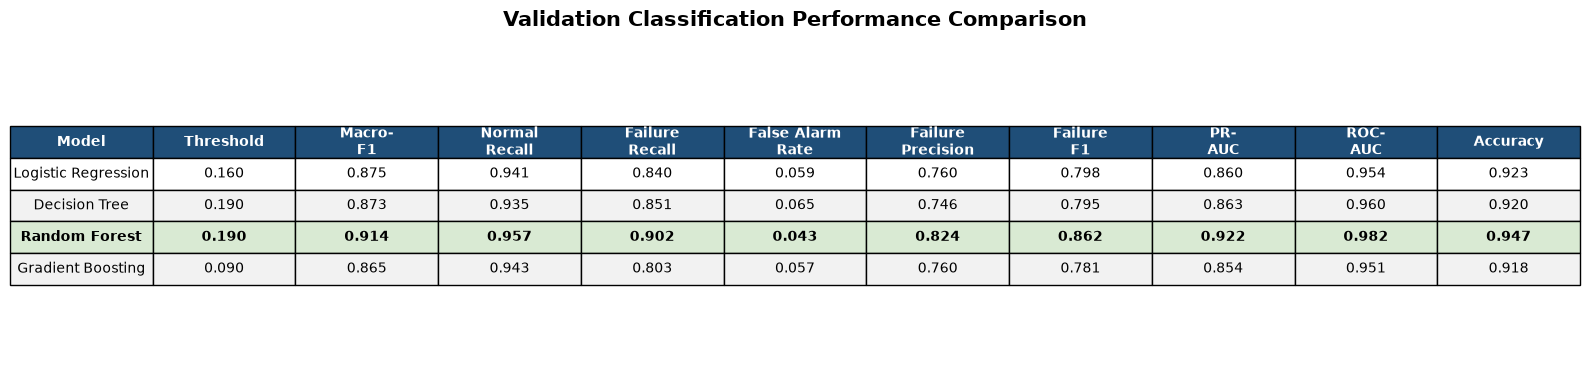

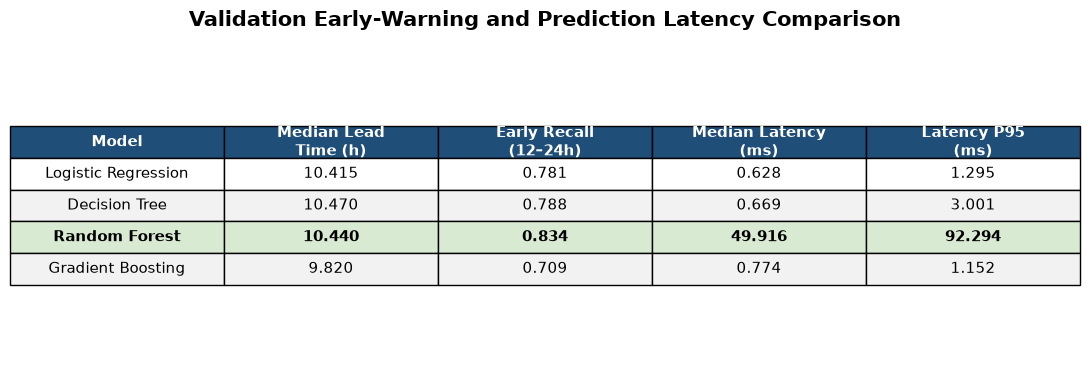

Saved figures:
1. validation_classification_metrics_table.png
2. validation_early_warning_latency_table.png


In [150]:
# Final validation results for all four models
comparison_df = updated_comparison.copy()


def create_table_figure(
    dataframe,
    title,
    filename,
    figure_size,
    font_size=10
):
    fig, ax = plt.subplots(figsize=figure_size)
    ax.axis('off')

    table = ax.table(
        cellText=dataframe.values,
        colLabels=dataframe.columns,
        cellLoc='center',
        colLoc='center',
        loc='center'
    )

    table.auto_set_font_size(False)
    table.set_fontsize(font_size)
    table.scale(1, 1.8)

    number_of_columns = len(dataframe.columns)

    # Format header
    for column_index in range(number_of_columns):
        header_cell = table[(0, column_index)]
        header_cell.set_facecolor('#1F4E78')
        header_cell.set_text_props(
            color='white',
            weight='bold'
        )

    # Format rows
    for row_index in range(1, len(dataframe) + 1):
        model_name = dataframe.iloc[row_index - 1]['Model']

        for column_index in range(number_of_columns):
            cell = table[(row_index, column_index)]

            # Highlight the selected model
            if model_name == 'Random Forest':
                cell.set_facecolor('#D9EAD3')
                cell.set_text_props(weight='bold')

            # Alternate row colors
            elif row_index % 2 == 0:
                cell.set_facecolor('#F2F2F2')

            else:
                cell.set_facecolor('white')

    ax.set_title(
        title,
        fontsize=15,
        weight='bold',
        pad=18
    )

    plt.tight_layout()

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches='tight',
        facecolor='white'
    )

    plt.show()


# =========================================================
# TABLE 1: Classification Performance
# =========================================================

classification_columns = [
    'Model',
    'Threshold',
    'Macro-F1',
    'Normal Recall',
    'Failure Recall',
    'False Alarm Rate',
    'Failure Precision',
    'Failure F1',
    'PR-AUC',
    'ROC-AUC',
    'Accuracy'
]

classification_table = comparison_df[
    classification_columns
].copy()

# Format numeric values to three decimal places
for column in classification_columns[1:]:
    classification_table[column] = classification_table[column].map(
        lambda value: f'{value:.3f}'
    )

# Format long column names
classification_table.columns = [
    'Model',
    'Threshold',
    'Macro-\nF1',
    'Normal\nRecall',
    'Failure\nRecall',
    'False Alarm\nRate',
    'Failure\nPrecision',
    'Failure\nF1',
    'PR-\nAUC',
    'ROC-\nAUC',
    'Accuracy'
]

create_table_figure(
    dataframe=classification_table,
    title='Validation Classification Performance Comparison',
    filename='validation_classification_metrics_table.png',
    figure_size=(16, 3.8),
    font_size=10
)


# =========================================================
# TABLE 2: Early-Warning and Prediction Latency
# =========================================================

operational_columns = [
    'Model',
    'Median Lead Time (h)',
    'Early Recall (12-24h)',
    'Latency (ms)',
    'Latency P95 (ms)'
]

operational_table = comparison_df[
    operational_columns
].copy()

# Format numeric values to three decimal places
for column in operational_columns[1:]:
    operational_table[column] = operational_table[column].map(
        lambda value: f'{value:.3f}'
    )

# Format long column names
operational_table.columns = [
    'Model',
    'Median Lead\nTime (h)',
    'Early Recall\n(12–24h)',
    'Median Latency\n(ms)',
    'Latency P95\n(ms)'
]

create_table_figure(
    dataframe=operational_table,
    title='Validation Early-Warning and Prediction Latency Comparison',
    filename='validation_early_warning_latency_table.png',
    figure_size=(11, 3.8),
    font_size=11
)

print('Saved figures:')
print('1. validation_classification_metrics_table.png')
print('2. validation_early_warning_latency_table.png')

### Validation Model Performance Comparison

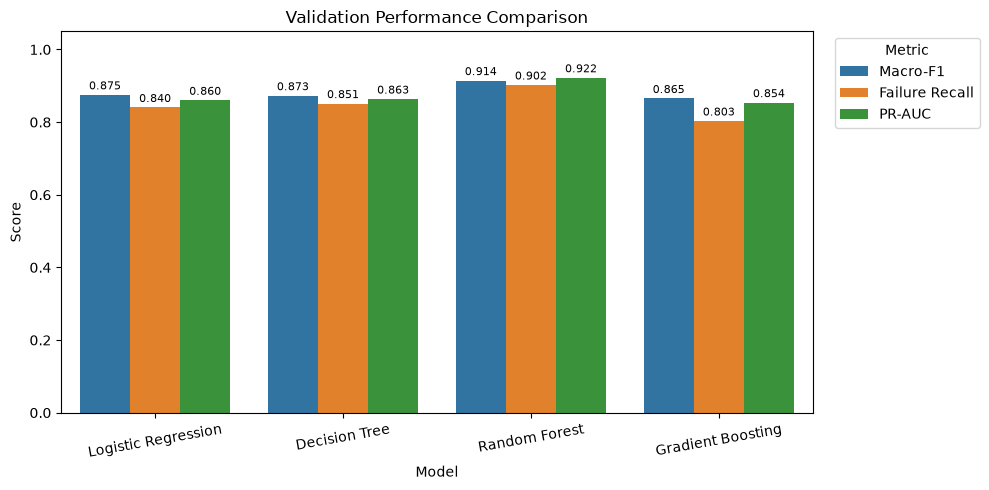

In [151]:
# Compare the main validation metrics.
comparison_plot = updated_comparison[
    [
        'Model',
        'Macro-F1',
        'Failure Recall',
        'PR-AUC'
    ]
].melt(
    id_vars='Model',
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=comparison_plot,
    x='Model',
    y='Score',
    hue='Metric'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.3f',
        padding=2,
        fontsize=8
    )

plt.ylim(0, 1.05)
plt.xlabel('Model')
plt.ylabel('Score')
plt.title('Validation Performance Comparison')
plt.legend(
    title='Metric',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

### False Alarm Rate Comparison

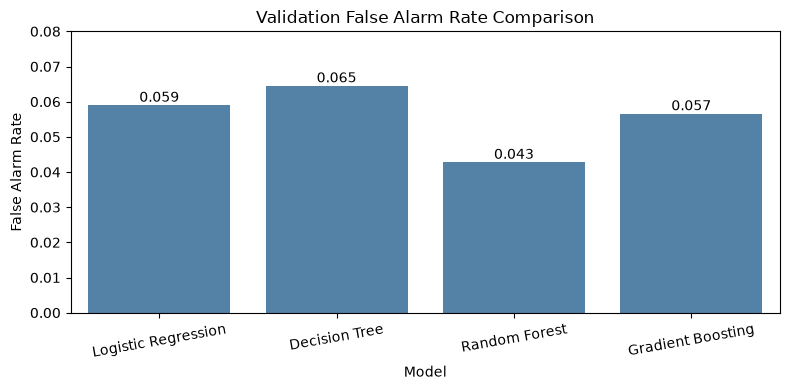

In [152]:
# Compare the validation False Alarm Rate.
plt.figure(figsize=(8, 4))

ax = sns.barplot(
    data=updated_comparison,
    x='Model',
    y='False Alarm Rate',
    color='steelblue'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.3f'
    )

plt.xlabel('Model')
plt.ylabel('False Alarm Rate')
plt.title('Validation False Alarm Rate Comparison')
plt.ylim(0, 0.08)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

### Early-Warning Recall Comparison

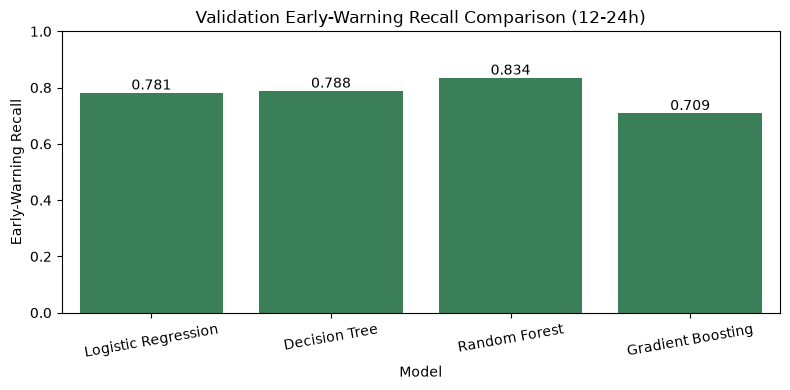

In [153]:
# Compare early-warning recall on validation data.
plt.figure(figsize=(8, 4))

ax = sns.barplot(
    data=updated_comparison,
    x='Model',
    y='Early Recall (12-24h)',
    color='seagreen'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.3f'
    )

plt.xlabel('Model')
plt.ylabel('Early-Warning Recall')
plt.title('Validation Early-Warning Recall Comparison (12-24h)')
plt.ylim(0, 1)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

### Prediction Latency Comparison

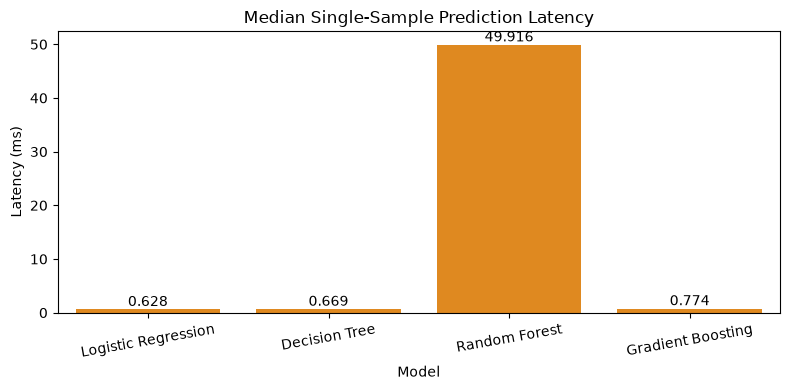

In [154]:
# Compare median prediction latency.
plt.figure(figsize=(8, 4))

ax = sns.barplot(
    data=updated_comparison,
    x='Model',
    y='Latency (ms)',
    color='darkorange'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.3f'
    )

plt.xlabel('Model')
plt.ylabel('Latency (ms)')
plt.title('Median Single-Sample Prediction Latency')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

## Final Model Selection

In [155]:
# Select the model with the highest validation Macro-F1.
best_model_row = updated_comparison.loc[
    updated_comparison['Macro-F1'].idxmax()
]

print('Selected Model:', best_model_row['Model'])
print('Validation Macro-F1:',
      round(best_model_row['Macro-F1'], 3))

Selected Model: Random Forest
Validation Macro-F1: 0.914


## Risk State Threshold Selection

In [156]:
# Find a high-confidence threshold using validation data.
high_risk_results = []

high_risk_grid = np.arange(
    selected_threshold_RFC + 0.01,
    1.00,
    0.01
)

for threshold in high_risk_grid:

    high_risk_pred = (
        y_prob_val_RFC >= threshold
    ).astype(int)

    high_risk_results.append({
        'Threshold': threshold,

        'Precision': metrics.precision_score(
            y_validation,
            high_risk_pred,
            zero_division=0
        ),

        'Recall': metrics.recall_score(
            y_validation,
            high_risk_pred,
            zero_division=0
        ),

        'Number of Alerts': high_risk_pred.sum()
    })

high_risk_results = pd.DataFrame(
    high_risk_results
)

high_risk_candidates = high_risk_results[
    high_risk_results['Precision'] >= 0.90
].sort_values(
    ['Recall', 'Threshold'],
    ascending=[False, True]
)

high_risk_candidates.head(10).round(3)

,Threshold,Precision,Recall,Number of Alerts
17,0.37,0.904,0.746,532
18,0.38,0.906,0.732,521
19,0.39,0.914,0.721,509
20,0.40,0.918,0.709,498
21,0.41,0.918,0.698,490
22,0.42,0.919,0.684,480
23,0.43,0.927,0.667,464
24,0.44,0.929,0.648,450
25,0.45,0.932,0.636,440
26,0.46,0.932,0.619,428


In [157]:
# Store the selected risk state thresholds.
warning_threshold = round(
    float(selected_threshold_RFC),
    2
)

high_risk_threshold = round(
    float(high_risk_candidates.iloc[0]['Threshold']),
    2
)

print('Normal: probability <',
      warning_threshold)

print('Warning:',
      warning_threshold,
      '<= probability <',
      high_risk_threshold)

print('High Risk: probability >=',
      high_risk_threshold)

Normal: probability < 0.19
High Risk: probability >= 0.37


The Warning threshold was selected by maximizing validation Macro-F1. The High Risk threshold was selected as the threshold with the highest recall while maintaining at least 90% precision on the validation data.

## Final Test Evaluation

In [158]:
# Evaluate the selected model on the test data.
y_prob_test_RFC = RFC.predict_proba(X_test)[:, 1]

y_pred_test_RFC = (
    y_prob_test_RFC >= selected_threshold_RFC
).astype(int)

test_confusion_matrix = metrics.confusion_matrix(
    y_test,
    y_pred_test_RFC
)

tn_test, fp_test, fn_test, tp_test = (
    test_confusion_matrix.ravel()
)

print('Selected Threshold:',
      round(selected_threshold_RFC, 2))

print('\nConfusion Matrix:')
print(test_confusion_matrix)

print('\nClassification Report:')
print(metrics.classification_report(
    y_test,
    y_pred_test_RFC,
    target_names=['Normal', 'Failure'],
    digits=3
))

Selected Threshold: 0.19

Confusion Matrix:
[[3655  271]
 [  42  598]]

Classification Report:
              precision    recall  f1-score   support

      Normal      0.989     0.931     0.959      3926
     Failure      0.688     0.934     0.793       640

    accuracy                          0.931      4566
   macro avg      0.838     0.933     0.876      4566
weighted avg      0.947     0.931     0.936      4566



In [159]:
# Store the final test results.
RFC_test_results = pd.DataFrame([{
    'Model': 'Random Forest',
    'Threshold': selected_threshold_RFC,

    'Macro-F1': metrics.f1_score(
        y_test,
        y_pred_test_RFC,
        average='macro'
    ),

    'Normal Recall': tn_test / (
        tn_test + fp_test
    ),

    'Failure Recall': tp_test / (
        tp_test + fn_test
    ),

    'False Alarm Rate': fp_test / (
        fp_test + tn_test
    ),

    'Failure Precision': metrics.precision_score(
        y_test,
        y_pred_test_RFC
    ),

    'Failure F1': metrics.f1_score(
        y_test,
        y_pred_test_RFC
    ),

    'PR-AUC': metrics.average_precision_score(
        y_test,
        y_prob_test_RFC
    ),

    'ROC-AUC': metrics.roc_auc_score(
        y_test,
        y_prob_test_RFC
    ),

    'Accuracy': metrics.accuracy_score(
        y_test,
        y_pred_test_RFC
    )
}])

RFC_test_results.round(3)

,Model,Threshold,Macro-F1,Normal Recall,Failure Recall,False Alarm Rate,Failure Precision,Failure F1,PR-AUC,ROC-AUC,Accuracy
0,Random Forest,0.19,0.876,0.931,0.934,0.069,0.688,0.793,0.894,0.979,0.931


### Test Early-Warning Performance

In [160]:
# Calculate early-warning performance on the test set.
rul_test = test_metadata['rul_hours'].values

true_positive_mask_test = (
    (y_test.values == 1) &
    (y_pred_test_RFC == 1)
)

median_lead_time_test_RFC = test_metadata.loc[
    true_positive_mask_test,
    'rul_hours'
].median()

early_period_mask_test = (
    (y_test.values == 1) &
    (rul_test >= 12) &
    (rul_test <= 24)
)

early_warning_recall_test_RFC = y_pred_test_RFC[
    early_period_mask_test
].mean()

print('Median Warning Lead Time:',
      round(median_lead_time_test_RFC, 3),
      'hours')

print('Early-Warning Recall (12-24h):',
      round(early_warning_recall_test_RFC, 3))

Median Warning Lead Time: 11.07 hours
Early-Warning Recall (12-24h): 0.878


In [161]:
# Add early-warning and latency results.
RFC_test_results['Median Lead Time (h)'] = (
    median_lead_time_test_RFC
)

RFC_test_results['Early Recall (12-24h)'] = (
    early_warning_recall_test_RFC
)

RFC_test_results['Latency (ms)'] = (
    prediction_latency_RF
)

RFC_test_results['Latency P95 (ms)'] = (
    latency_p95_RF
)

RFC_test_results.round(3)

,Model,Threshold,Macro-F1,Normal Recall,Failure Recall,False Alarm Rate,Failure Precision,Failure F1,PR-AUC,ROC-AUC,Accuracy,Median Lead Time (h),Early Recall (12-24h),Latency (ms),Latency P95 (ms)
0,Random Forest,0.19,0.876,0.931,0.934,0.069,0.688,0.793,0.894,0.979,0.931,11.07,0.878,49.916,92.294


### Final Model Target Check

In [162]:
# Check whether the final model meets the project targets.
target_check = pd.DataFrame({
    'Metric': [
        'Macro-F1',
        'Failure Recall',
        'False Alarm Rate',
        'Early-Warning Recall (12-24h)',
        'Median Prediction Latency'
    ],

    'Result': [
        RFC_test_results.loc[0, 'Macro-F1'],
        RFC_test_results.loc[0, 'Failure Recall'],
        RFC_test_results.loc[0, 'False Alarm Rate'],
        RFC_test_results.loc[0, 'Early Recall (12-24h)'],
        RFC_test_results.loc[0, 'Latency (ms)']
    ],

    'Target': [
        '>= 0.80',
        '>= 0.80',
        '<= 0.10',
        '>= 0.75',
        '<= 100 ms'
    ],

    'Target Met': [
        RFC_test_results.loc[0, 'Macro-F1'] >= 0.80,
        RFC_test_results.loc[0, 'Failure Recall'] >= 0.80,
        RFC_test_results.loc[0, 'False Alarm Rate'] <= 0.10,
        RFC_test_results.loc[0, 'Early Recall (12-24h)'] >= 0.75,
        RFC_test_results.loc[0, 'Latency (ms)'] <= 100
    ]
})

target_check.round(3)

,Metric,Result,Target,Target Met
0,Macro-F1,0.876,>= 0.80,True
1,Failure Recall,0.934,>= 0.80,True
2,False Alarm Rate,0.069,<= 0.10,True
3,Early-Warning Recall (12-24h),0.878,>= 0.75,True
4,Median Prediction Latency,49.916,<= 100 ms,True


### Final Model Target Achievement

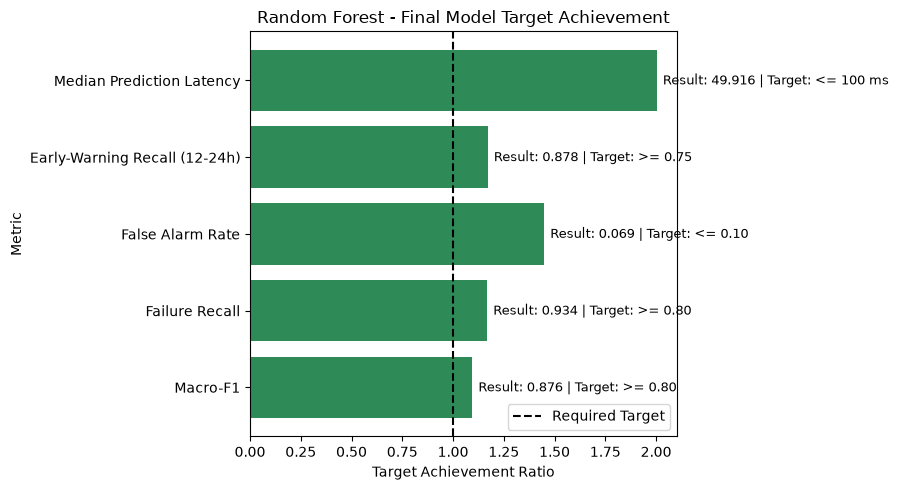

In [163]:
# Visualize achievement of the evaluation targets.
target_values = np.array([
    0.80,   # Macro-F1
    0.80,   # Failure Recall
    0.10,   # False Alarm Rate
    0.75,   # Early-Warning Recall
    100.0   # Prediction Latency
])

result_values = target_check['Result'].values

# Higher is better for recall and F1.
# Lower is better for false alarms and latency.
achievement_scores = np.array([
    result_values[0] / target_values[0],
    result_values[1] / target_values[1],
    target_values[2] / result_values[2],
    result_values[3] / target_values[3],
    target_values[4] / result_values[4]
])

colors = [
    'seagreen' if met else 'firebrick'
    for met in target_check['Target Met']
]

plt.figure(figsize=(9, 5))

bars = plt.barh(
    target_check['Metric'],
    achievement_scores,
    color=colors
)

# Target achievement line.
plt.axvline(
    1.0,
    color='black',
    linestyle='--',
    label='Required Target'
)

for index, bar in enumerate(bars):

    result = result_values[index]
    target = target_check.loc[index, 'Target']

    plt.text(
        bar.get_width() + 0.03,
        bar.get_y() + bar.get_height() / 2,
        f'Result: {result:.3f} | Target: {target}',
        va='center',
        fontsize=9
    )

plt.xlabel('Target Achievement Ratio')
plt.ylabel('Metric')
plt.title('Random Forest - Final Model Target Achievement')
plt.legend()
plt.tight_layout()

plt.savefig(
    'final_model_target_achievement.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Validation and Test Comparison

In [164]:
# Compare validation and test performance.
RFC_validation_summary = RFC_validation_results.copy()
RFC_validation_summary.insert(0, 'Dataset', 'Validation')

RFC_test_summary = RFC_test_results.copy()
RFC_test_summary.insert(0, 'Dataset', 'Test')

RFC_final_comparison = pd.concat(
    [
        RFC_validation_summary,
        RFC_test_summary
    ],
    ignore_index=True
)

RFC_final_comparison.round(3)

,Dataset,Model,Threshold,Macro-F1,Normal Recall,Failure Recall,False Alarm Rate,Failure Precision,Failure F1,PR-AUC,ROC-AUC,Accuracy,Median Lead Time (h),Early Recall (12-24h),Latency (ms),Latency P95 (ms)
0,Validation,Random Forest,0.19,0.914,0.957,0.902,0.043,0.824,0.862,0.922,0.982,0.947,10.44,0.834,49.916,92.294
1,Test,Random Forest,0.19,0.876,0.931,0.934,0.069,0.688,0.793,0.894,0.979,0.931,11.07,0.878,49.916,92.294


### Test Confusion Matrix Visualization

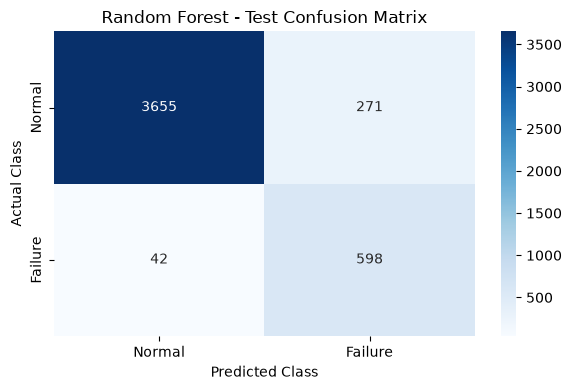

In [165]:
# Visualize the test confusion matrix.
plt.figure(figsize=(6, 4))

sns.heatmap(
    test_confusion_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Failure'],
    yticklabels=['Normal', 'Failure']
)

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Random Forest - Test Confusion Matrix')
plt.tight_layout()
plt.show()

### Test ROC Curve

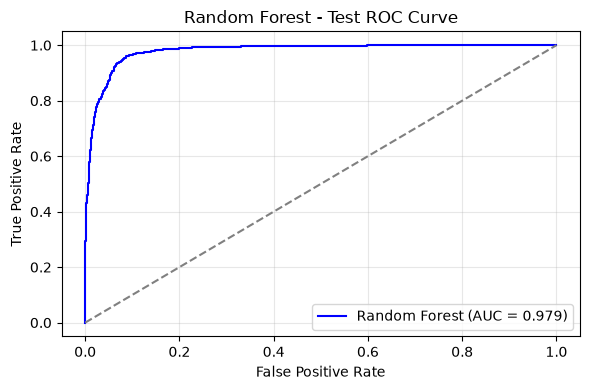

In [166]:
# Calculate the ROC curve.
false_positive_rate, true_positive_rate, cutoffs = (
    metrics.roc_curve(
        y_test,
        y_prob_test_RFC
    )
)

test_roc_auc = metrics.roc_auc_score(
    y_test,
    y_prob_test_RFC
)

# Visualize the ROC curve.
plt.figure(figsize=(6, 4))

plt.plot(
    false_positive_rate,
    true_positive_rate,
    color='blue',
    label=f'Random Forest (AUC = {test_roc_auc:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    color='gray'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest - Test ROC Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Test Precision-Recall Curve

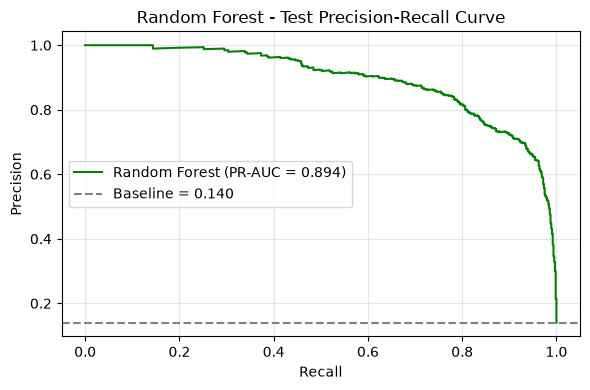

In [167]:
# Calculate the Precision-Recall curve.
precision_values, recall_values, cutoffs = (
    metrics.precision_recall_curve(
        y_test,
        y_prob_test_RFC
    )
)

test_pr_auc = metrics.average_precision_score(
    y_test,
    y_prob_test_RFC
)

failure_rate = y_test.mean()

# Visualize the Precision-Recall curve.
plt.figure(figsize=(6, 4))

plt.plot(
    recall_values,
    precision_values,
    color='green',
    label=f'Random Forest (PR-AUC = {test_pr_auc:.3f})'
)

plt.axhline(
    y=failure_rate,
    linestyle='--',
    color='gray',
    label=f'Baseline = {failure_rate:.3f}'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Random Forest - Test Precision-Recall Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Final Model Interpretation

### Random Forest Feature Importance

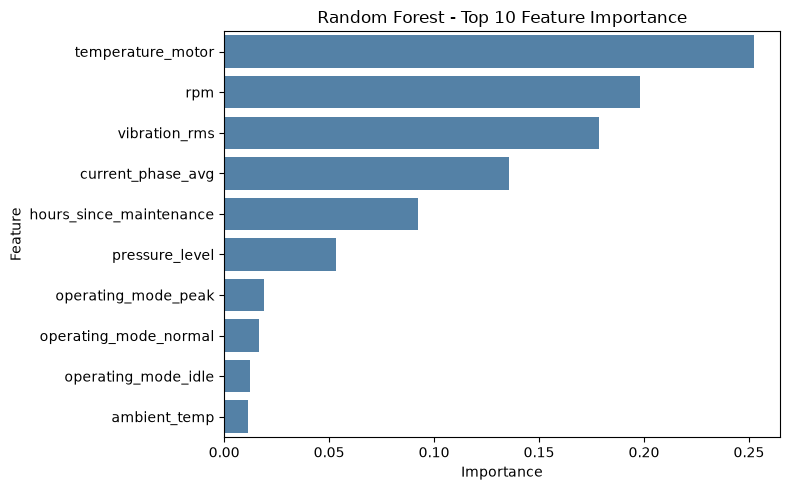

In [168]:
# Display the top 10 most important features.
top_features_RFC = RFC_feature_importance.head(10)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=top_features_RFC,
    x='Importance',
    y='Feature',
    color='steelblue'
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest - Top 10 Feature Importance')
plt.tight_layout()
plt.show()

## Final Risk State Assignment

In [174]:
# Assign the final risk states to test predictions.
test_risk_states = np.select(
    [
        y_prob_test_RFC < warning_threshold,
        y_prob_test_RFC < high_risk_threshold
    ],
    [
        'Normal',
        'Warning'
    ],
    default='High Risk'
)

# Create final prediction output for the LLM
llm_input = test_metadata.copy()

llm_input['failure_probability'] = y_prob_test_RFC
llm_input['predicted_failure'] = y_pred_test_RFC
llm_input['risk_state'] = test_risk_states

print(llm_input.head())

   machine_id           timestamp  failure_within_24h  rul_hours  \
0           6 2024-01-01 00:00:00                   0      93.33   
1           6 2024-01-01 00:05:00                   0      93.25   
2           6 2024-01-01 00:26:00                   0      92.90   
3           6 2024-01-01 00:40:00                   0      92.67   
4           6 2024-01-01 01:01:00                   0      92.32   

   failure_probability  predicted_failure risk_state  
0             0.043811                  0     Normal  
1             0.046087                  0     Normal  
2             0.048327                  0     Normal  
3             0.047580                  0     Normal  
4             0.050894                  0     Normal  


In [170]:
# Summarize the predicted risk states.
risk_state_summary = (
    test_predictions['risk_state']
    .value_counts()
    .reindex(
        ['Normal', 'Warning', 'High Risk'],
        fill_value=0
    )
    .rename_axis('Risk State')
    .reset_index(name='Count')
)

risk_state_summary['Percentage'] = (
    risk_state_summary['Count'] /
    len(test_predictions) * 100
)

risk_state_summary.round(2)

,Risk State,Count,Percentage
0,Normal,3697,80.97
1,Warning,344,7.53
2,High Risk,525,11.50


In [171]:
# Create final prediction output for the LLM
llm_input = test_metadata.copy()

llm_input['failure_probability'] = y_prob_test_RFC
llm_input['predicted_failure'] = y_pred_test_RFC
llm_input['risk_state'] = test_risk_states

print(llm_input.head())

   machine_id           timestamp  failure_within_24h  rul_hours  \
0           6 2024-01-01 00:00:00                   0      93.33   
1           6 2024-01-01 00:05:00                   0      93.25   
2           6 2024-01-01 00:26:00                   0      92.90   
3           6 2024-01-01 00:40:00                   0      92.67   
4           6 2024-01-01 01:01:00                   0      92.32   

   failure_probability  predicted_failure risk_state  
0             0.043811                  0     Normal  
1             0.046087                  0     Normal  
2             0.048327                  0     Normal  
3             0.047580                  0     Normal  
4             0.050894                  0     Normal  


### Predicted Risk State Distribution

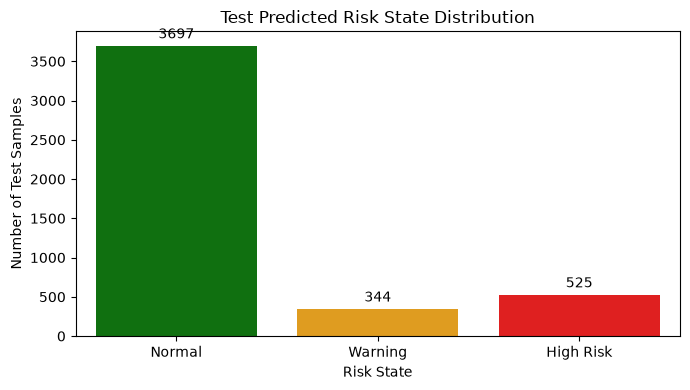

In [172]:
# Visualize the predicted risk state distribution.
plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=risk_state_summary,
    x='Risk State',
    y='Count',
    hue='Risk State',
    palette={
        'Normal': 'green',
        'Warning': 'orange',
        'High Risk': 'red'
    },
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%d',
        padding=3
    )

plt.xlabel('Risk State')
plt.ylabel('Number of Test Samples')
plt.title('Test Predicted Risk State Distribution')
plt.tight_layout()
plt.show()

## Saving the Final Results

In [173]:
# Save the final project files in organized folders.


# --------------------------------------------------
# Create output folders
# --------------------------------------------------

output_folder = 'MachineSense_Final_Project_Files'

dashboard_folder = os.path.join(
    output_folder,
    '01_dashboard_files'
)

evaluation_folder = os.path.join(
    output_folder,
    '02_evaluation_results'
)

predictions_folder = os.path.join(
    output_folder,
    '03_predictions'
)

selection_folder = os.path.join(
    output_folder,
    '04_model_selection'
)

interpretation_folder = os.path.join(
    output_folder,
    '05_model_interpretation'
)

other_models_folder = os.path.join(
    output_folder,
    '06_other_models'
)

figures_folder = os.path.join(
    output_folder,
    '07_figures'
)

folders = [
    dashboard_folder,
    evaluation_folder,
    predictions_folder,
    selection_folder,
    interpretation_folder,
    other_models_folder,
    figures_folder
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)


# --------------------------------------------------
# Create summary tables
# --------------------------------------------------

risk_state_thresholds = pd.DataFrame({
    'Risk State': [
        'Normal',
        'Warning',
        'High Risk'
    ],

    'Minimum Probability': [
        0.00,
        warning_threshold,
        high_risk_threshold
    ],

    'Maximum Probability': [
        warning_threshold,
        high_risk_threshold,
        1.00
    ],

    'Rule': [
        f'Probability < {warning_threshold}',
        f'{warning_threshold} <= Probability < {high_risk_threshold}',
        f'Probability >= {high_risk_threshold}'
    ]
})


selected_thresholds = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],

    'Selected Threshold': [
        selected_threshold_LR,
        selected_threshold_DTC,
        selected_threshold_RFC,
        selected_threshold_GBC
    ]
})


feature_names = pd.DataFrame({
    'Feature': X_train.columns
})


validation_predictions = validation_metadata.copy()

validation_predictions['LR_probability'] = (
    y_prob_validation_LR
)

validation_predictions['LR_prediction'] = (
    y_pred_validation_LR
)

validation_predictions['DTC_probability'] = (
    y_prob_validation_DTC
)

validation_predictions['DTC_prediction'] = (
    y_pred_validation_DTC
)

validation_predictions['RFC_probability'] = (
    y_prob_val_RFC
)

validation_predictions['RFC_prediction'] = (
    y_pred_val_RFC
)

validation_predictions['GBC_probability'] = (
    y_prob_val_GBC
)

validation_predictions['GBC_prediction'] = (
    y_pred_val_GBC
)


dashboard_predictions = test_predictions[
    [
        'machine_id',
        'timestamp',
        'failure_probability',
        'predicted_failure',
        'risk_state'
    ]
].copy()


final_model_info = pd.DataFrame([{
    'Selected Model': 'Random Forest',

    'Warning Threshold': warning_threshold,

    'High Risk Threshold': high_risk_threshold,

    'Validation Macro-F1':
        RFC_validation_results.loc[0, 'Macro-F1'],

    'Test Macro-F1':
        RFC_test_results.loc[0, 'Macro-F1'],

    'Test Failure Recall':
        RFC_test_results.loc[0, 'Failure Recall'],

    'Test False Alarm Rate':
        RFC_test_results.loc[0, 'False Alarm Rate'],

    'Test PR-AUC':
        RFC_test_results.loc[0, 'PR-AUC'],

    'Test ROC-AUC':
        RFC_test_results.loc[0, 'ROC-AUC'],

    'Test Accuracy':
        RFC_test_results.loc[0, 'Accuracy'],

    'Test Early-Warning Recall':
        RFC_test_results.loc[
            0,
            'Early Recall (12-24h)'
        ],

    'Median Prediction Latency (ms)':
        RFC_test_results.loc[0, 'Latency (ms)']
}])


test_confusion_matrix_table = pd.DataFrame(
    test_confusion_matrix,

    index=[
        'Actual Normal',
        'Actual Failure'
    ],

    columns=[
        'Predicted Normal',
        'Predicted Failure'
    ]
)


# --------------------------------------------------
# 1. Save dashboard files
# --------------------------------------------------

joblib.dump(
    RFC,
    os.path.join(
        dashboard_folder,
        'FINAL_random_forest_model.joblib'
    )
)

dashboard_predictions.to_csv(
    os.path.join(
        dashboard_folder,
        'dashboard_predictions.csv'
    ),
    index=False
)

risk_state_thresholds.to_csv(
    os.path.join(
        dashboard_folder,
        'risk_state_thresholds.csv'
    ),
    index=False
)

final_model_info.to_csv(
    os.path.join(
        dashboard_folder,
        'final_model_info.csv'
    ),
    index=False
)

feature_names.to_csv(
    os.path.join(
        dashboard_folder,
        'feature_names.csv'
    ),
    index=False
)


# --------------------------------------------------
# 2. Save evaluation results
# --------------------------------------------------

evaluation_files = {
    'model_comparison_validation.csv':
        updated_comparison,

    'random_forest_test_results.csv':
        RFC_test_results,

    'random_forest_validation_test_comparison.csv':
        RFC_final_comparison,

    'risk_state_summary.csv':
        risk_state_summary,

    'model_evaluation_targets.csv':
        evaluation_targets,

    'final_model_target_check.csv':
        target_check
}

for file_name, dataframe in evaluation_files.items():

    dataframe.to_csv(
        os.path.join(
            evaluation_folder,
            file_name
        ),
        index=False
    )


test_confusion_matrix_table.to_csv(
    os.path.join(
        evaluation_folder,
        'random_forest_test_confusion_matrix.csv'
    )
)


# --------------------------------------------------
# 3. Save prediction files
# --------------------------------------------------

validation_predictions.to_csv(
    os.path.join(
        predictions_folder,
        'validation_predictions_all_models.csv'
    ),
    index=False
)

test_predictions.to_csv(
    os.path.join(
        predictions_folder,
        'test_predictions_full.csv'
    ),
    index=False
)


# --------------------------------------------------
# 4. Save model-selection details
# --------------------------------------------------

selection_files = {
    'LR_parameter_results.csv':
        LR_tuning_results,

    'DTC_parameter_results.csv':
        DTC_tuning_results,

    'RFC_parameter_results.csv':
        rf_tuning_df,

    'GBC_parameter_results.csv':
        gb_tuning_df,

    'LR_threshold_comparison.csv':
        LR_threshold_comparison,

    'DTC_threshold_comparison.csv':
        DTC_threshold_comparison,

    'RFC_threshold_comparison.csv':
        RFC_threshold_comparison,

    'GBC_threshold_comparison.csv':
        GBC_threshold_comparison,

    'RFC_all_threshold_results.csv':
        threshold_comparison_rf,

    'GBC_all_threshold_results.csv':
        threshold_comparison_gb,

    'selected_model_thresholds.csv':
        selected_thresholds,

    'high_risk_threshold_results.csv':
        high_risk_results,

    'high_risk_threshold_candidates.csv':
        high_risk_candidates,

    'RFC_overfitting_check.csv':
        rf_overfitting_results,

    'GBC_overfitting_check.csv':
        gb_overfitting_results
}

for file_name, dataframe in selection_files.items():

    dataframe.to_csv(
        os.path.join(
            selection_folder,
            file_name
        ),
        index=False
    )


# --------------------------------------------------
# 5. Save model-interpretation results
# --------------------------------------------------

interpretation_files = {
    'logistic_regression_coefficients.csv':
        LR_coefficients,

    'decision_tree_feature_importance.csv':
        DTC_feature_importance,

    'random_forest_feature_importance.csv':
        RFC_feature_importance,

    'gradient_boosting_feature_importance.csv':
        GBC_feature_importance
}

for file_name, dataframe in interpretation_files.items():

    dataframe.to_csv(
        os.path.join(
            interpretation_folder,
            file_name
        ),
        index=False
    )


# --------------------------------------------------
# 6. Save other trained models
# --------------------------------------------------

joblib.dump(
    LR,
    os.path.join(
        other_models_folder,
        'logistic_regression_model.joblib'
    )
)

joblib.dump(
    DTC,
    os.path.join(
        other_models_folder,
        'decision_tree_model.joblib'
    )
)

joblib.dump(
    GBC,
    os.path.join(
        other_models_folder,
        'gradient_boosting_model.joblib'
    )
)


# --------------------------------------------------
# Create README file
# --------------------------------------------------

readme_lines = [
    'MachineSense Final Project Files',
    '',
    'Selected model: Random Forest',
    '',
    'Risk-state thresholds:',
    f'- Normal: probability < {warning_threshold}',
    (
        f'- Warning: {warning_threshold} <= probability '
        f'< {high_risk_threshold}'
    ),
    f'- High Risk: probability >= {high_risk_threshold}',
    '',
    'Main dashboard folder:',
    '01_dashboard_files',
    '',
    'Final model:',
    '01_dashboard_files/FINAL_random_forest_model.joblib',
    '',
    'Dashboard prediction file:',
    '01_dashboard_files/dashboard_predictions.csv',
    '',
    'The model expects 14 preprocessed features.',
    'Use the exact order stored in feature_names.csv.',
    '',
    'Do not use these columns as model features:',
    '- machine_id',
    '- timestamp',
    '- failure_within_24h',
    '- failure_type',
    '- rul_hours',
    '- estimated_repair_cost',
    '',
    'Use MachineSense_Processed_Data_with_Metadata.zip',
    'for processed data and preprocessing information.'
]

readme_text = '\n'.join(readme_lines)

with open(
    os.path.join(
        output_folder,
        'README.txt'
    ),
    'w',
    encoding='utf-8'
) as readme_file:

    readme_file.write(readme_text)


print('Final project files saved successfully.')
print('Output folder:', output_folder)

Final project files saved successfully.
Output folder: MachineSense_Final_Project_Files
